# Personal Finance Tracker — 02 Categorisation & Prediction

Two applied tasks: **auto-categorise** a transaction from its amount + timing, and look at how **predictable** monthly spend is. All numbers are run.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import utils
df=utils.load_transactions()

## 1. Auto-categorising transactions

In [2]:
clf,acc=utils.classify_category(df)
print('category classifier accuracy: %.3f (9 categories, chance ~0.11)'%acc)

category classifier accuracy: 0.306 (9 categories, chance ~0.11)


## 2. Why it's hard — amounts overlap across categories

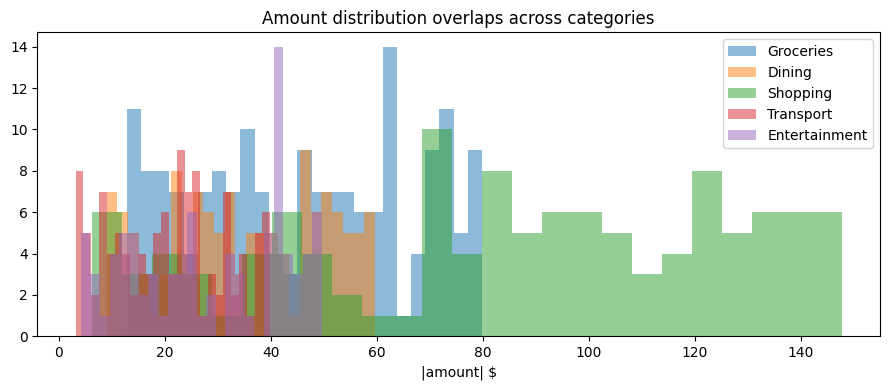

In [3]:
exp=df[df.amount<0]
fig,ax=plt.subplots(figsize=(9,4)); 
for c in exp.category.value_counts().head(5).index: ax.hist(exp[exp.category==c].amount.abs(),bins=25,alpha=0.5,label=c)
ax.legend(); ax.set_title('Amount distribution overlaps across categories'); ax.set_xlabel('|amount| $'); plt.tight_layout(); plt.show()

## 3. Monthly spend — trend & simple forecast

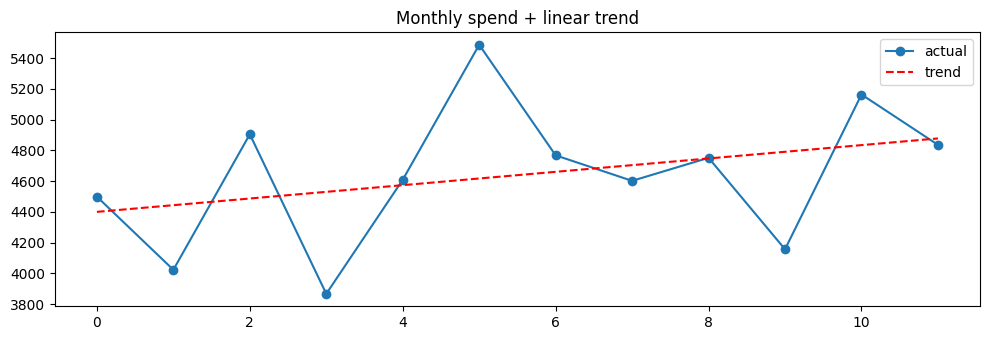

next-month spend (trend extrapolation): $4921


In [4]:
ms=utils.monthly_spend(df).reset_index(drop=True)
from numpy.polynomial import polynomial as Poly
x=np.arange(len(ms)); coef=np.polyfit(x,ms.values,1)
fig,ax=plt.subplots(figsize=(10,3.5)); ax.plot(x,ms.values,'o-',label='actual'); ax.plot(x,np.polyval(coef,x),'--',color='red',label='trend'); ax.legend(); ax.set_title('Monthly spend + linear trend'); plt.tight_layout(); plt.show()
print('next-month spend (trend extrapolation): $%.0f'%np.polyval(coef,len(ms)))

## 4. Summary & takeaways

- **Auto-categorisation from amount + timing alone is weak (~0.31 accuracy)** — better than chance (~0.11 for 9 classes) but far from reliable, because **spend amounts overlap heavily across categories** (a \$40 charge could be groceries, dining, or transport).
- **The honest lesson**: real transaction categorisation needs the *merchant/description* text (an NLP problem), not just the number — amount is a weak feature.
- **Monthly spend is stable and roughly forecastable** by a simple trend line — useful for budgeting, though a personal budget's value is in flagging the outlier months, not the average.
- A practical tracker would combine rule/keyword matching on descriptions with this statistical layer.